<a href="https://colab.research.google.com/github/Pujari5555/AI-ML/blob/main/ANNexp4_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**AIM**: To implement feedforward multi-layer networks and apply them to the MNIST and CIFAR-10 datasets using python.

**The code below implements Rosenblatt's perceptron algorithm with a fixed number of iterations (100 times). We
use a constant learning rate 0.5 for simplicity.**

In [ ]:
import numpy as np
# Training data for NAND.
x = np.array([
[0, 0, 1], [0, 1, 1], [1, 0, 1], [1, 1, 1]])
y = np.array([0, 0, 0, 1])
w = np.array([0.0, 0.0, 0.0])
eta = 0.5
for t in range(100):
  for i in range(len(y)):
    y_pred = np.heaviside(np.dot(x[i], w), 0)
    w += (y[i] - y_pred) * eta * x[i]


In [ ]:
w

array([ 1. ,  0.5, -1. ])

In [ ]:
np.heaviside(np.dot(x, w), 0)


array([0., 0., 0., 1.])

**The code below implements this idea. The function np.heaviside() yields a vector corresponding to the four
predictions, applying the step function for every element of the argument.
This technique is frequently used in mini-batch training**

In [ ]:
import numpy as np
# Training data for NAND.
x = np.array([[0, 0, 1], [0, 1, 1], [1, 0, 1], [1, 1, 1]])
y = np.array([1, 1, 1, 0])
w = np.array([0.0, 0.0, 0.0])
eta = 0.5
for t in range(100):
  y_pred = np.heaviside(np.dot(x, w), 0)
  w += np.dot((y - y_pred), x)


In [ ]:
w

array([-1., -1.,  2.])

In [ ]:
np.heaviside(np.dot(x, w), 0)


array([1., 1., 1., 0.])

**Stochastic gradient descent (SGD) with mini-batch**

In [ ]:
import numpy as np
def sigmoid(v):
  return 1.0 / (1 + np.exp(-v))
# Training data for NAND.
x = np.array([[0, 0, 1], [0, 1, 1], [1, 0, 1], [1, 1, 1]])
y = np.array([1, 1, 1, 0])
w = np.array([0.0, 0.0, 0.0])
eta = 0.5
for t in range(100):
  y_pred = sigmoid(np.dot(x, w))
  w -= np.dot((y_pred - y), x)


In [ ]:
w

array([-5.59504346, -5.59504346,  8.57206068])

In [ ]:
sigmoid(np.dot(x, w))


array([0.99981071, 0.95152498, 0.95152498, 0.06798725])

**Automatic differentiation**

**Using autograd
Installing autograd (do this once).**

In [ ]:
!pip install autograd

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
import autograd
import autograd.numpy as np
def loss(w, x):
  return -np.log(1.0 / (1 + np.exp(-np.dot(x, w))))
x = np.array([1, 1, 1])
w = np.array([1.0, 1.0, -1.5])
grad_loss = autograd.grad(loss)
print(loss(w, x))
print(grad_loss(w, x))


0.47407698418010663
[-0.37754067 -0.37754067 -0.37754067]


**Using pytorch**

In [ ]:
!pip install torch torchvision

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
import torch
dtype = torch.float
x = torch.tensor([1, 1, 1], dtype=dtype)
w = torch.tensor([1.0, 1.0, -1.5], dtype=dtype, requires_grad=True)
loss = -torch.dot(x, w).sigmoid().log()
loss.backward()
print(loss.item())
print(w.grad)


0.4740769565105438
tensor([-0.3775, -0.3775, -0.3775])


In [ ]:
import torch
dtype = torch.float
# Training data for NAND.
x = torch.tensor([[0, 0, 1], [0, 1, 1], [1, 0, 1], [1, 1, 1]], dtype=dtype)
y = torch.tensor([[1], [1], [1], [0]], dtype=dtype)
w = torch.randn(3, 1, dtype=dtype, requires_grad=True)
eta = 0.5
for t in range(100):
  y_pred = x.mm(w).sigmoid()
  ll = y * y_pred + (1 - y) * (1 - y_pred)
  loss = -ll.log().sum() # The loss value.
  loss.backward() # Compute the gradients of the loss.
  with torch.no_grad():
    w -= eta * w.grad # Update weights using SGD.
    w.grad.zero_()

In [ ]:
w

tensor([[-4.3570],
        [-4.3550],
        [ 6.7244]], requires_grad=True)

In [ ]:
x.mm(w).sigmoid()


tensor([[0.9988],
        [0.9145],
        [0.9143],
        [0.1205]], grad_fn=<SigmoidBackward0>)

In [ ]:
import torch
dtype = torch.float
# Training data for XOR
x = torch.tensor([[0, 0, 1], [0, 1, 1], [1, 0, 1], [1, 1, 1]], dtype=dtype)
y = torch.tensor([[0], [1], [1], [0]], dtype=dtype)
w1 = torch.randn(3, 2, dtype=dtype, requires_grad=True)
w2 = torch.randn(2, 1, dtype=dtype, requires_grad=True)
b2 = torch.randn(1, 1, dtype=dtype, requires_grad=True)
eta = 0.5
for t in range(1000):
  y_pred = x.mm(w1).sigmoid().mm(w2).add(b2).sigmoid()
  ll = y * y_pred + (1 - y) * (1 - y_pred)
  loss = -ll.log().sum()
  loss.backward()
  with torch.no_grad():
    w1 -= eta * w1.grad
    print(w1.grad)
    w2 -= eta * w2.grad
    b2 -= eta * b2.grad
    w1.grad.zero_()
    w2.grad.zero_()
    b2.grad.zero_()


In [ ]:
print(w1)
print(w2)
print(b2)


tensor([[-7.0567,  5.2851],
        [-7.1159,  5.2933],
        [ 2.8935, -8.1943]], requires_grad=True)
tensor([[-11.6257],
        [-11.8712]], requires_grad=True)
tensor([[5.7694]], requires_grad=True)


In [ ]:
x.mm(w1).sigmoid().mm(w2).add(b2).sigmoid()

tensor([[0.0052],
        [0.9932],
        [0.9932],
        [0.0061]], grad_fn=<SigmoidBackward0>)

**Single-layer neural network with high-level NN modules**

In [ ]:
import torch
dtype = torch.float
# Training data for NAND.
x = torch.tensor([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=dtype)
y = torch.tensor([[1], [1], [1], [0]], dtype=dtype)
# Define a neural network using high-level modules.
model = torch.nn.Sequential(torch.nn.Linear(2, 1, bias=True))
loss_fn = torch.nn.BCEWithLogitsLoss(size_average=False)
eta = 0.5
for t in range(100):
  y_pred = model(x) # Make predictions.
  loss = loss_fn(y_pred, y) # Compute the loss.
  model.zero_grad() # Zero-clear the gradients.
  loss.backward() # Compute the gradients.
  with torch.no_grad():
    for param in model.parameters():
      param -= eta * param.grad

In [ ]:
model.state_dict()


OrderedDict([('0.weight', tensor([[-4.2724, -4.2718]])),
             ('0.bias', tensor([6.5997]))])

In [ ]:
model(x).sigmoid()

tensor([[0.9986],
        [0.9112],
        [0.9111],
        [0.1251]], grad_fn=<SigmoidBackward0>)

**Multi-layer neural network with high-level NN modules**

In [ ]:
import torch
dtype = torch.float
# Training data for XOR.
x = torch.tensor([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=dtype)
y = torch.tensor([[0], [1], [1], [0]], dtype=dtype)
# Define a neural network using high-level modules.
model = torch.nn.Sequential(torch.nn.Linear(2, 2, bias=True),torch.nn.Sigmoid(),torch.nn.Linear(2, 1, bias=True))
# Binary corss-entropy loss after sigmoid function.
loss_fn = torch.nn.BCEWithLogitsLoss(size_average=False)
eta = 0.5
for t in range(1000):
  y_pred = model(x) # Make predictions.
  loss = loss_fn(y_pred, y) # Compute the loss.
  model.zero_grad() # Zero-clear the gradients.
  loss.backward() # Compute the gradients.
  with torch.no_grad():
    for param in model.parameters():
      param -= eta * param.grad

In [ ]:
model.state_dict()


OrderedDict([('0.weight', tensor([[ 6.4201,  6.4204],
                      [-6.8715, -6.8716]])),
             ('0.bias', tensor([-0.3030,  0.6053])),
             ('2.weight', tensor([[ 3.8055, -5.5985]])),
             ('2.bias', tensor([-3.1071]))])

In [ ]:
model(x).sigmoid()

tensor([[0.0060],
        [0.6636],
        [0.6636],
        [0.6678]], grad_fn=<SigmoidBackward0>)

In [ ]:
import torch
dtype = torch.float
x = torch.tensor([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=dtype)
y = torch.tensor([[1], [1], [1], [0]], dtype=dtype)
model = torch.nn.Sequential(torch.nn.Linear(2, 1, bias=True))
loss_fn = torch.nn.BCEWithLogitsLoss(size_average=False)
optimizer = torch.optim.SGD(model.parameters(), lr=0.5)
for t in range(100):
  y_pred = model(x) # Make predictions.
  loss = loss_fn(y_pred, y) # Compute the loss.
  optimizer.zero_grad() # Zero-clear gradients.
  loss.backward() # Compute the gradients.
  optimizer.step()

In [ ]:
model.state_dict()


OrderedDict([('0.weight', tensor([[-4.2260, -4.2264]])),
             ('0.bias', tensor([6.5314]))])

In [ ]:
model(x).sigmoid()

tensor([[0.9985],
        [0.9093],
        [0.9093],
        [0.1278]], grad_fn=<SigmoidBackward0>)

**Single-layer neural network with a customizable NN class.**

In [ ]:
import torch
dtype = torch.float
# Training data for NAND.
x = torch.tensor([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=dtype)
y = torch.tensor([[1], [1], [1], [0]], dtype=dtype)
# Define a neural network model.
class SingleLayerNN(torch.nn.Module):
  def __init__(self, d_in, d_out):
    super(SingleLayerNN, self).__init__()
    self.linear1 = torch.nn.Linear(d_in, d_out, bias=True)
    def forward(self, x):
      return self.linear1(x)
      model = SingleLayerNN(2, 1)
      loss_fn = torch.nn.BCEWithLogitsLoss(size_average=False)
      optimizer = torch.optim.SGD(model.parameters(), lr=0.5)
      for t in range(100):
        y_pred = model(x) # Make predictions.
        loss = loss_fn(y_pred, y) # Compute the loss.
        optimizer.zero_grad() # Zero-clear gradients.
        loss.backward() # Compute the gradients.
        optimizer.step()

In [ ]:
model.state_dict()

OrderedDict([('0.weight', tensor([[-4.2260, -4.2264]])),
             ('0.bias', tensor([6.5314]))])

In [ ]:
model(x).sigmoid()


tensor([[0.9985],
        [0.9093],
        [0.9093],
        [0.1278]], grad_fn=<SigmoidBackward0>)

**Multi-layer neural network with a customizable NN class.**

In [ ]:
import torch
dtype = torch.float
# Training data for XOR.
x = torch.tensor([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=dtype)
y = torch.tensor([[0], [1], [1], [0]], dtype=dtype)
# Define a neural network model.
class ThreeLayerNN(torch.nn.Module):
  def __init__(self, d_in, d_hidden, d_out):
    super(ThreeLayerNN, self).__init__()
    self.linear1 = torch.nn.Linear(d_in, d_hidden, bias=True)
    self.linear2 = torch.nn.Linear(d_hidden, d_out, bias=True)
  def forward(self, x):
    return self.linear2(self.linear1(x).sigmoid())
model = ThreeLayerNN(2, 2, 1)
loss_fn = torch.nn.BCEWithLogitsLoss(size_average=False)
# Optimizer based on SGD (change "SGD" to "Adam" to use Adam)
optimizer = torch.optim.SGD(model.parameters(), lr=0.5)
for t in range(1000):
  y_pred = model(x) # Make predictions.
  loss = loss_fn(y_pred, y) # Compute the loss.
  optimizer.zero_grad() # Zero-clear gradients.
  loss.backward() # Compute the gradients.
  optimizer.step() # Update the parameters using the gradients.


In [ ]:
model.state_dict()


OrderedDict([('linear1.weight', tensor([[ 5.1607,  5.1624],
                      [-6.8304, -6.8415]])),
             ('linear1.bias', tensor([-7.9998,  2.7605])),
             ('linear2.weight', tensor([[-11.2959, -11.1101]])),
             ('linear2.bias', tensor([5.4937]))])

In [ ]:
model(x).sigmoid()


tensor([[0.0070],
        [0.9908],
        [0.9908],
        [0.0082]], grad_fn=<SigmoidBackward0>)

# **Implement feedforward multi-layer networks and apply them to the MNIST and CIFAR-10 datasets**

**mnist datasets**

**step1: Importing the required libraries.**

In [ ]:
from keras.datasets import mnist
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.datasets import mnist
from tensorflow.keras import backend as K
import matplotlib.pyplot as plt
import numpy as np
import argparse as args

**Storing the mnistdata into variables(assumed variables).**

In [ ]:
# here mnist dataset is download and stored so, not required to download again.
(train_X, train_y), (test_X, test_y) = mnist.load_data()

11501568/11490434 [==============================] - 0s 0us/step


In MNIST dataset contain
* The training set contains 60k images and the testing set contains 10k images.
* The training input vector is of the dimension [60000 X 28 X 28].
* The training output vector is of the dimension [60000 X 1].
* Each individual input vector is of the dimension [28 X 28].
* Each individual output vector is of the dimension [1].

In [ ]:
print('X_train: ' + str(train_X.shape))
print('Y_train: ' + str(train_y.shape))
print('X_test:  '  + str(test_X.shape))
print('Y_test:  '  + str(test_y.shape))

X_train: (60000, 28, 28)
Y_train: (60000,)
X_test:  (10000, 28, 28)
Y_test:  (10000,)


**Each image in the MNIST dataset is represented as 28×28×1 pixel image.**
*  In order to train our neural network on the image data we first need to flatten the 2D images into a flat list of 28×28 = 784 values
* scaling the pixel intensities to the range [0, 1].

In [ ]:
train_X = train_X.reshape((train_X.shape[0], 28 * 28 * 1))
test_X = test_X.reshape((test_X.shape[0], 28 * 28 * 1))
train_X = train_X.astype("float32") / 255.0
test_X = test_X.astype("float32") / 255.0

* we first need to transform these integer labels into vector labels, where the index in the vector for label is set to 1 and 0 otherwise (this process is called **one-hot encoding**).
*  simply perform this process of one-hot encoding the input integer labels as vector labels for both the training and testing set.

In [ ]:
lb = LabelBinarizer()
train_Y = lb.fit_transform(train_y)
test_Y = lb.transform(test_y)

**Now define the 784-256-128-10 architecture using Keras.**
* The input_shape is set to 784, the dimensionality of each MNIST data points.
* We then learn 256 weights in this layer and apply the sigmoid activation function.
* The next layer learns 128 weights.
*  Finally, fully connected layer, this time only learning 10 weights, corresponding to the ten (0-9) output classes.
* Instead of a **sigmoid activation,** we’ll use a **softmax activation** to obtain normalized class probabilities for each prediction.

In [ ]:
model = Sequential()
model.add(Dense(256, input_shape=(784,), activation="sigmoid"))
model.add(Dense(128, activation="sigmoid"))
model.add(Dense(10, activation="softmax"))

* we initialize the SGD optimizer with a learning rate of 0.01*
* We’ll use the category cross-entropy loss function as our loss metric.
* Using the cross-entropy loss function is also why we had to convert our integer labels to vector labels.
* A call to **.fit** of the model kicks off the training of our neural network.
*The first involves you manually splitting your training data into a train and validation dataset and specifying the validation dataset to the fit() function via the validation_data argument.  

In [ ]:
sgd = SGD(0.01)
model.compile(loss="categorical_crossentropy", optimizer=sgd,
	metrics=["accuracy"])
H = model.fit(train_X, train_Y, validation_data=(test_X, test_Y),
	epochs=100, batch_size=128)

Epoch 1/100
469/469 [==============================] - 4s 3ms/step - loss: 2.2766 - accuracy: 0.1990 - val_loss: 2.2428 - val_accuracy: 0.2343
Epoch 2/100
469/469 [==============================] - 2s 3ms/step - loss: 2.2116 - accuracy: 0.3657 - val_loss: 2.1734 - val_accuracy: 0.4686
Epoch 3/100
469/469 [==============================] - 1s 3ms/step - loss: 2.1312 - accuracy: 0.5207 - val_loss: 2.0755 - val_accuracy: 0.5722
Epoch 4/100
469/469 [==============================] - 2s 3ms/step - loss: 2.0150 - accuracy: 0.5891 - val_loss: 1.9343 - val_accuracy: 0.5899
Epoch 5/100
469/469 [==============================] - 1s 3ms/step - loss: 1.8510 - accuracy: 0.6255 - val_loss: 1.7432 - val_accuracy: 0.6711
Epoch 6/100
469/469 [==============================] - 1s 3ms/step - loss: 1.6465 - accuracy: 0.6651 - val_loss: 1.5265 - val_accuracy: 0.7105
Epoch 7/100
469/469 [==============================] - 1s 3ms/step - loss: 1.4335 - accuracy: 0.7027 - val_loss: 1.3197 - val_accuracy: 0.7409

* A call to the .predict method of model will return the class label probabilities for every data point in testX.
* To determine the class with the largest probability, we can simply call .argmax(axis=1) as we do on Line 56, which will give us the index of the class label with the largest probability, and, therefore, our final output classification.
* Final classification report is displayed.

In [ ]:
predictions = model.predict(test_X, batch_size=128)
print(classification_report(test_Y.argmax(axis=1),
	predictions.argmax(axis=1),
	target_names=[str(x) for x in lb.classes_]))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96       980
           1       0.97      0.97      0.97      1135
           2       0.92      0.90      0.91      1032
           3       0.90      0.91      0.91      1010
           4       0.91      0.94      0.92       982
           5       0.90      0.87      0.88       892
           6       0.93      0.95      0.94       958
           7       0.94      0.92      0.93      1028
           8       0.90      0.89      0.89       974
           9       0.92      0.90      0.91      1009

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



**Accuracy is approx 92%**

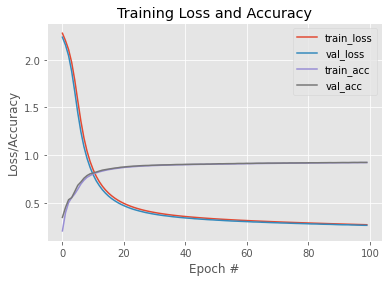

In [ ]:
# plot between training loss and accuracy
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, 100), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, 100), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, 100), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 100), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()


**CIFAR-10 datasets**

**Importing a required libraries.**

In [ ]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt
import numpy as np
import argparse

In [ ]:
# Storing the mnistdata into variables(assumed variables).
# here mnist dataset is download and stored so, not required to download again.
# A call to cifar10.load_data on Line 21 automatically loads the CIFAR-10 dataset
((trainX, trainY), (testX, testY)) = cifar10.load_data()
trainX = trainX.astype("float") / 255.0
testX = testX.astype("float") / 255.0
# reshaping the design matrix for the training and testing data. Recall that each image in the CIFAR-10 dataset is represented by a 32×32×3 image.
# To flatten each of the images in the training and testing sets, we simply use the .reshape function of NumPy.
trainX = trainX.reshape((trainX.shape[0], 3072))
testX = testX.reshape((testX.shape[0], 3072))
# converting integers to vectors
lb = LabelBinarizer()
trainY = lb.fit_transform(trainY)
testY = lb.transform(testY)
#initialize the label names for the CIFAR-10 dataset
labelNames = ["airplane", "automobile", "bird", "cat", "deer",
	"dog", "frog", "horse", "ship", "truck"]
# define the 3072-1024-512-10 architecture using Keras
# We then add the first Dense layer which has an input_shape of 3072, a node for each of the 3,072 flattened pixel values in the design matrix —
# this layer is then responsible for learning 1,024 weights.
# first we use a sigmoid activation function and a ReLU activation in hopes of improving network performance.
model = Sequential()
model.add(Dense(1024, input_shape=(3072,), activation="relu"))
model.add(Dense(512, activation="relu"))
model.add(Dense(10, activation="softmax"))
# We’ll use the SGD optimizer to train the network with a learning rate of 0.01
# Once the network has been trained, we can evaluate it using classification_report to obtain a more detailed review of model performance.
#
sgd = SGD(0.01)
model.compile(loss="categorical_crossentropy", optimizer=sgd,
	metrics=["accuracy"])
H = model.fit(trainX, trainY, validation_data=(testX, testY),
	epochs=100, batch_size=32)

Epoch 1/100
1563/1563 [==============================] - 7s 4ms/step - loss: 1.8351 - accuracy: 0.3446 - val_loss: 1.7490 - val_accuracy: 0.3840
Epoch 2/100
1563/1563 [==============================] - 7s 4ms/step - loss: 1.6492 - accuracy: 0.4175 - val_loss: 1.6636 - val_accuracy: 0.4197
Epoch 3/100
1563/1563 [==============================] - 6s 4ms/step - loss: 1.5689 - accuracy: 0.4456 - val_loss: 1.5406 - val_accuracy: 0.4502
Epoch 4/100
1563/1563 [==============================] - 6s 4ms/step - loss: 1.5100 - accuracy: 0.4657 - val_loss: 1.5764 - val_accuracy: 0.4340
Epoch 5/100
1563/1563 [==============================] - 6s 4ms/step - loss: 1.4644 - accuracy: 0.4844 - val_loss: 1.4999 - val_accuracy: 0.4632
Epoch 6/100
1563/1563 [==============================] - 6s 4ms/step - loss: 1.4203 - accuracy: 0.4988 - val_loss: 1.4397 - val_accuracy: 0.4904
Epoch 7/100
1563/1563 [==============================] - 6s 4ms/step - loss: 1.3850 - accuracy: 0.5125 - val_loss: 1.5049 - val_ac

**Once the network has been trained, we can evaluate it using classification_report to obtain a more detailed review of model performance:**

In [ ]:
predictions = model.predict(testX, batch_size=32)
print(classification_report(testY.argmax(axis=1),
	predictions.argmax(axis=1), target_names=labelNames))

              precision    recall  f1-score   support

    airplane       0.64      0.63      0.63      1000
  automobile       0.68      0.66      0.67      1000
        bird       0.47      0.47      0.47      1000
         cat       0.40      0.37      0.38      1000
        deer       0.48      0.52      0.50      1000
         dog       0.45      0.43      0.44      1000
        frog       0.63      0.62      0.63      1000
       horse       0.63      0.60      0.62      1000
        ship       0.67      0.71      0.69      1000
       truck       0.58      0.61      0.60      1000

    accuracy                           0.56     10000
   macro avg       0.56      0.56      0.56     10000
weighted avg       0.56      0.56      0.56     10000



**accuracy is 56**

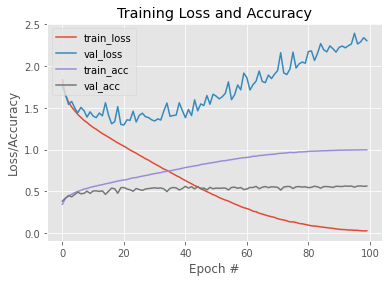

In [ ]:
# plot the training loss and accuracy
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, 100), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, 100), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, 100), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 100), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()